# Sentiment Analysis of Product Reviews
## Notebook 1: Data Loading, EDA & Text Preprocessing

## 0. IMPORTS

In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")  # non-interactive backend for saving
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

## CONSTANTS

In [3]:
# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
RANDOM_STATE   = 42
TEST_SIZE      = 0.2
TOP_K_CHI2     = 500
TOP_K_MI       = 300
TFIDF_MAX_FEAT = 15000
PLOTS_DIR      = "plots"
MODELS_DIR     = "saved_models"

# Built-in English stopwords (no NLTK download required)
STOPWORDS = {
    "a","about","above","after","again","against","all","am","an","and","any","are",
    "aren't","as","at","be","because","been","before","being","below","between","both",
    "but","by","can't","cannot","could","couldn't","did","didn't","do","does","doesn't",
    "doing","don't","down","during","each","few","for","from","further","get","got","had",
    "hadn't","has","hasn't","have","haven't","having","he","he'd","he'll","he's","her",
    "here","here's","hers","herself","him","himself","his","how","how's","i","i'd","i'll",
    "i'm","i've","if","in","into","is","isn't","it","it's","its","itself","let's","me",
    "more","most","mustn't","my","myself","no","nor","not","of","off","on","once","only",
    "or","other","ought","our","ours","ourselves","out","over","own","same","shan't","she",
    "she'd","she'll","she's","should","shouldn't","so","some","such","than","that","that's",
    "the","their","theirs","them","themselves","then","there","there's","these","they",
    "they'd","they'll","they're","they've","this","those","through","to","too","under",
    "until","up","very","was","wasn't","we","we'd","we'll","we're","we've","were",
    "weren't","what","what's","when","when's","where","where's","which","while","who",
    "who's","whom","why","why's","will","with","won't","would","wouldn't","you","you'd",
    "you'll","you're","you've","your","yours","yourself","yourselves","just","also",
    "however","therefore","furthermore","thus","hence","indeed","still","yet","though",
    "although","since","while","unless","whether","either","neither","both","each",
    "every","much","many","more","most","such","no","nor","not","only","own","same","so"
}

# Negation words for linguistic feature
NEGATION_WORDS = {
    "not","no","never","none","nobody","nothing","neither","nor","nowhere",
    "hardly","barely","scarcely","doesn't","didn't","don't","won't","wouldn't",
    "couldn't","shouldn't","isn't","aren't","wasn't","weren't","haven't","hasn't",
    "hadn't","can't","cannot","shan't","mustn't","needn't","daren't","without"
}

SENTIMENT_MAP = {1: "Negative", 2: "Negative", 3: "Neutral", 4: "Positive", 5: "Positive"}
SENTIMENT_ORDER = ["Negative", "Neutral", "Positive"]
PALETTE = {"Negative": "#E74C3C", "Neutral": "#F39C12", "Positive": "#27AE60"}

## SECTION 1 – DATA LOADING

In [4]:
def load_dataset(filepath: str) -> pd.DataFrame:

    print(f"\n{'='*60}")
    print("SECTION 1: DATA LOADING")
    print(f"{'='*60}")

    print(f"  ► Loading file: {filepath}")

    # Read CSV
    try:
        df = pd.read_csv(
            filepath,
            on_bad_lines="skip",
            encoding="utf-8",
            engine="python"
)
    except UnicodeDecodeError:
        df = pd.read_csv(
            filepath,
            on_bad_lines="skip",
            encoding="latin-1",
            engine="python"
)

    print(f"  ► Raw shape: {df.shape}")
    print(f"  ► Columns  : {list(df.columns)}")

    # Detect columns
    text_col = "Review Text"
    rating_col = "Rating"

    df = df[[text_col, rating_col]].copy()
    df.columns = ["review_text", "rating"]

    # 🔥 FIXED rating extraction
    df["rating"] = df["rating"].astype(str).str.extract(r'(\d)').astype(float)

    # Clean
    df = df.dropna(subset=["review_text", "rating"])
    df = df[df["rating"].between(1, 5)]
    df["rating"] = df["rating"].astype(int)

    # Safety check
    if len(df) == 0:
        raise ValueError("All rows removed. Check rating format.")

    # Map sentiment
    df["sentiment"] = df["rating"].map(SENTIMENT_MAP)

    print(f"  ► Clean shape : {df.shape}")
    print(f"\n  Sentiment distribution:")

    counts = df["sentiment"].value_counts()

    for s in SENTIMENT_ORDER:
        n = counts.get(s, 0)
        pct = 100 * n / len(df)
        print(f"    {s:10s}: {n:6,d}  ({pct:.1f}%)")

    return df.reset_index(drop=True)

## SECTION 2 – TEXT PREPROCESSING

In [5]:
def clean_text(text: str) -> str:
    """
    Clean a single review string:
      1. Lowercase
      2. Strip HTML tags
      3. Remove special characters / numbers
      4. Collapse whitespace
      5. Remove stopwords
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove special characters and digits, keep letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords (single-pass via join/split)
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]

    return " ".join(tokens)


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply text cleaning to the dataset and add a 'cleaned_text' column.
    """
    print(f"\n{'='*60}")
    print("SECTION 2: TEXT PREPROCESSING")
    print(f"{'='*60}")

    before = len(df)
    df = df.dropna(subset=["review_text"]).copy()
    df = df[df["review_text"].str.strip() != ""]
    print(f"  ► Rows after null/empty drop : {len(df):,}  (removed {before-len(df):,})")

    print("  ► Cleaning text (lowercase, HTML removal, special chars, stopwords)…")
    df["cleaned_text"] = df["review_text"].apply(clean_text)

    # Drop rows where cleaning left empty strings
    df = df[df["cleaned_text"].str.strip() != ""].reset_index(drop=True)
    print(f"  ► Final rows after cleaning  : {len(df):,}")

    # Sample stats
    avg_len = df["cleaned_text"].str.split().str.len().mean()
    print(f"  ► Avg tokens per review      : {avg_len:.1f}")

    return df



```
# This is formatted as code
```

## SECTION 3 – VISUALISATIONS (Basic EDA Plots)

In [6]:
def save_plot(fig, name: str):
    os.makedirs(PLOTS_DIR, exist_ok=True)
    path = os.path.join(PLOTS_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  ► Saved: {path}")


def plot_sentiment_distribution(df: pd.DataFrame):
    """Bar + pie chart of sentiment distribution."""
    counts = df["sentiment"].value_counts().reindex(SENTIMENT_ORDER)
    colors = [PALETTE[s] for s in SENTIMENT_ORDER]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Sentiment Distribution", fontsize=16, fontweight="bold")

    # Bar chart
    axes[0].bar(SENTIMENT_ORDER, counts.values, color=colors, edgecolor="white",
                linewidth=1.2, width=0.55)
    axes[0].set_xlabel("Sentiment", fontsize=12)
    axes[0].set_ylabel("Count", fontsize=12)
    axes[0].set_title("Review Counts by Sentiment")
    for i, (v, c) in enumerate(zip(counts.values, colors)):
        axes[0].text(i, v + counts.max() * 0.01, f"{v:,}", ha="center",
                     fontsize=11, fontweight="bold", color=c)

    # Pie chart
    wedges, texts, autotexts = axes[1].pie(
        counts.values, labels=SENTIMENT_ORDER, colors=colors,
        autopct="%1.1f%%", startangle=140,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight("bold")
    axes[1].set_title("Sentiment Proportions")

    plt.tight_layout()
    save_plot(fig, "01_sentiment_distribution.png")


def plot_review_length(df: pd.DataFrame):
    """Histogram of review word counts per sentiment class."""
    df = df.copy()
    df["word_count"] = df["cleaned_text"].str.split().str.len()

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.suptitle("Review Length Distribution by Sentiment", fontsize=16, fontweight="bold")

    for sent in SENTIMENT_ORDER:
        subset = df.loc[df["sentiment"] == sent, "word_count"]
        ax.hist(subset, bins=50, alpha=0.55, label=sent,
                color=PALETTE[sent], edgecolor="none")

    ax.set_xlabel("Word Count (cleaned)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.legend(fontsize=11)
    ax.set_xlim(0, 200)
    plt.tight_layout()
    save_plot(fig, "02_review_length_distribution.png")


SECTION 1: DATA LOADING
  ► Loading file: Amazon_Reviews.csv
  ► Raw shape: (21214, 9)
  ► Columns  : ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']
  ► Clean shape : (21055, 3)

  Sentiment distribution:
    Negative  : 14,350  (68.2%)
    Neutral   :    885  (4.2%)
    Positive  :  5,820  (27.6%)

SECTION 2: TEXT PREPROCESSING
  ► Rows after null/empty drop : 21,055  (removed 0)
  ► Cleaning text (lowercase, HTML removal, special chars, stopwords)…
  ► Final rows after cleaning  : 21,055
  ► Avg tokens per review      : 40.8
  ► Saved: plots/01_sentiment_distribution.png
  ► Saved: plots/02_review_length_distribution.png


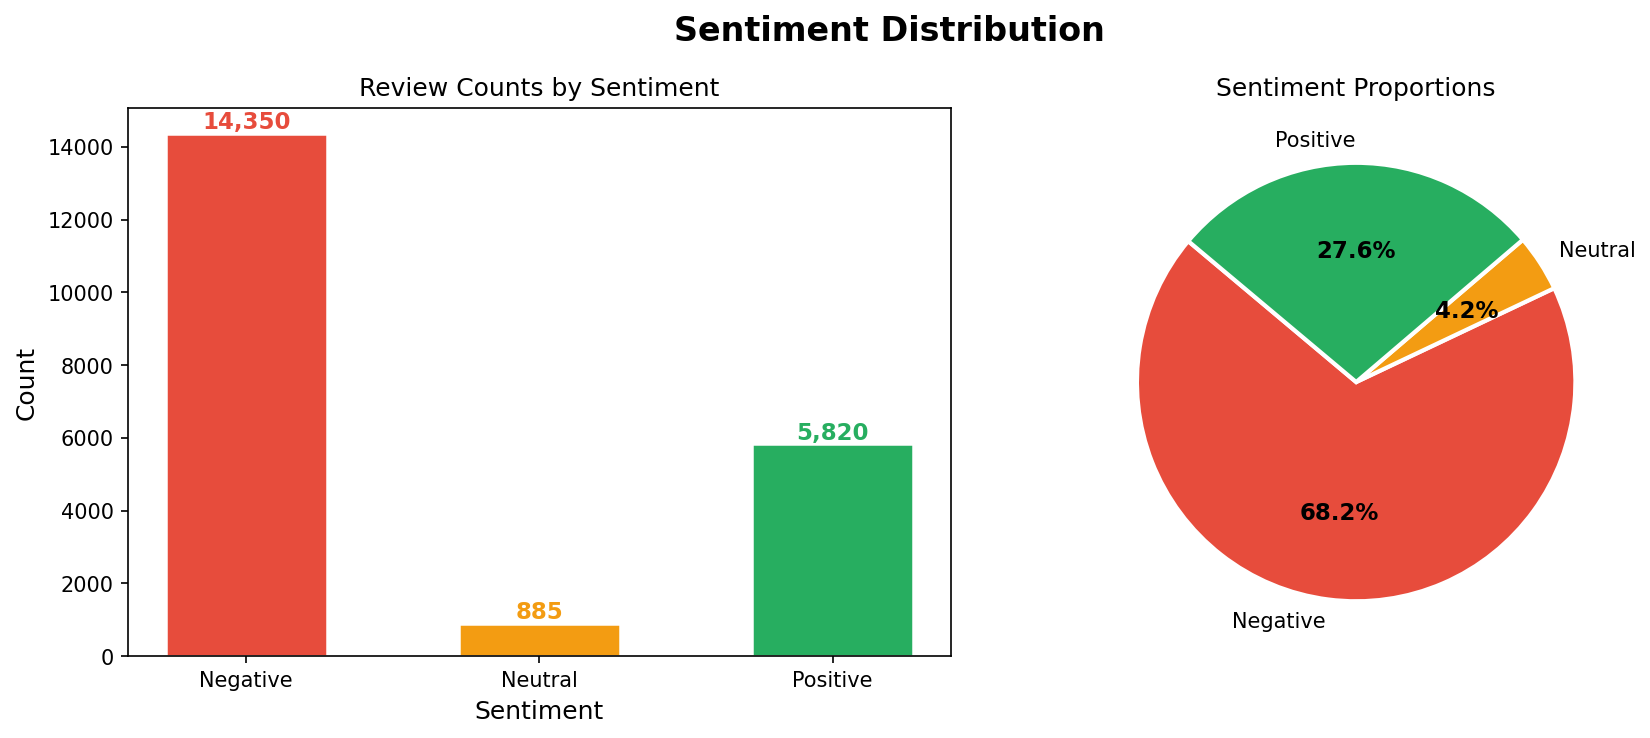

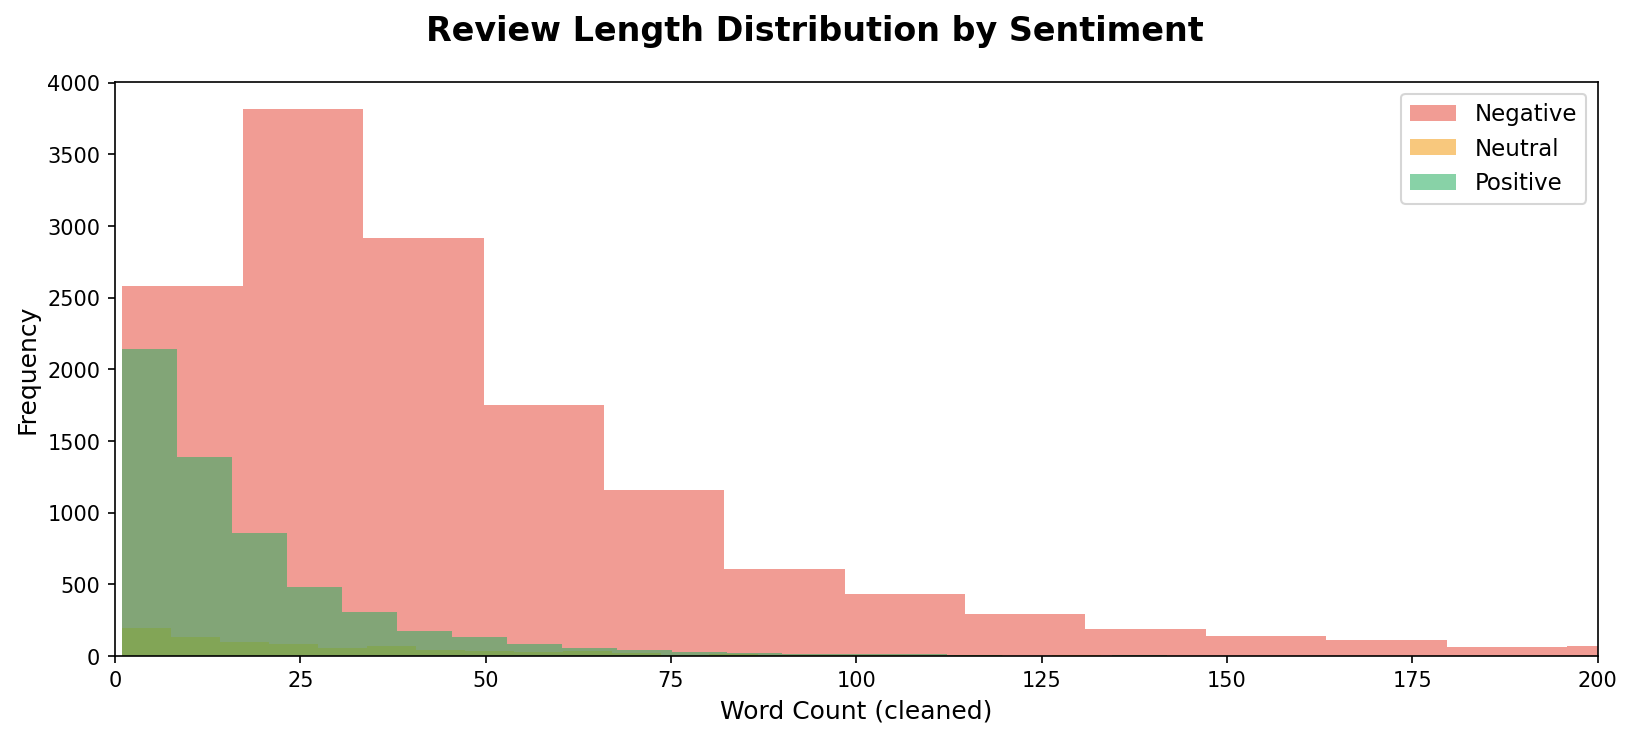

,count
sentiment,
Negative,14350
Positive,5820
Neutral,885


In [7]:
df = load_dataset("Amazon_Reviews.csv")
df = preprocess(df)

plot_sentiment_distribution(df)
plot_review_length(df)

from IPython.display import Image, display

display(Image("plots/01_sentiment_distribution.png"))
display(Image("plots/02_review_length_distribution.png"))

df.head()
df['sentiment'].value_counts()

## EDA Summary
- Dataset is imbalanced
- Negative dominates
- Neutral is small

## Impact on Modeling
- May bias predictions
- Need better metrics (F1)

## Final Insights from EDA

- The dataset is highly imbalanced, with negative reviews dominating the distribution.
- Neutral reviews are significantly fewer, which may affect model learning.
- Review length varies across sentiments, indicating possible differences in user expression patterns.

### Implications:
- Models may become biased toward predicting negative sentiment.
- Evaluation should focus on metrics like Macro F1 instead of accuracy.
- Techniques such as class balancing or weighting may improve performance.